In [ ]:
!pip install numpy torch rasterio transformers matplotlib scikit-image


In [6]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import rasterio
from transformers import Dinov2Model
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from matplotlib.patches import Rectangle

In [7]:
class SpaceNetDatasetTorch(Dataset):
    def __init__(self, images_folder, masks_folder):
        self.image_paths = sorted(glob.glob(os.path.join(images_folder, "*.tif")))
        self.masks_folder = masks_folder

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Read the image.
        image_path = self.image_paths[idx]
        with rasterio.open(image_path) as src_img:
            img_data = src_img.read()  # shape: (bands, H, W)
            img_data = np.transpose(img_data, (1, 2, 0))  # shape: (H, W, channels)

        # Build the expected mask filename.
        base_name = os.path.splitext(os.path.basename(image_path))[0]  # e.g. "RGB-PanSharpen_AOI_2_Vegas_img4817"
        mask_name = base_name + "_mask.tif"                             # e.g. "RGB-PanSharpen_AOI_2_Vegas_img4817_mask.tif"
        mask_path = os.path.join(self.masks_folder, mask_name)

        # Read the mask if it exists; otherwise, create a blank mask.
        if os.path.exists(mask_path):
            with rasterio.open(mask_path) as src_mask:
                mask_data = src_mask.read(1)  # single band -> shape: (H, W)
        else:
            h, w, _ = img_data.shape
            mask_data = np.zeros((h, w), dtype=np.uint8)

        # Convert image and mask data to proper types.
        img_data = img_data.astype(np.float32)
        # Normalize image values to [0, 1]
        img_data = img_data / 255.0

        mask_data = mask_data.astype(np.uint8)
        # Expand mask to have a single channel: (H, W, 1)
        mask_data = np.expand_dims(mask_data, axis=-1)

        # Convert to torch tensors and transpose to (channels, H, W)
        image_tensor = torch.tensor(img_data.transpose(2, 0, 1), dtype=torch.float32)
        mask_tensor  = torch.tensor(mask_data.transpose(2, 0, 1), dtype=torch.float32)

        return image_tensor, mask_tensor

In [8]:
processed_images_folder = "Geoestimation/dataset/processed_images/AOI_2_Vegas_Train/RGB-PanSharpen-processed"
processed_masks_folder  = "Geoestimation/dataset/processed_masks/AOI_2_Vegas_Train/geojson"

In [9]:
# Create dataset and dataloader.
dataset = SpaceNetDatasetTorch(processed_images_folder, processed_masks_folder)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True)

In [10]:
model_name = "facebook/dinov2-base"

In [11]:
dino_backbone = Dinov2Model.from_pretrained(model_name, output_hidden_states=True)

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dino_backbone.to(device)

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2SdpaAttention(
          (attention): Dinov2SdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_pa

In [13]:
class DinoV2SegmentationModel(nn.Module):
    def __init__(self, backbone):
        super(DinoV2SegmentationModel, self).__init__()
        self.backbone = backbone
        # Determine the hidden size from the backbone configuration; default to 768 if not provided.
        hidden_size = getattr(self.backbone.config, "hidden_size", 768)
        # Define a segmentation head (decoder) using a few convolutional layers.
        self.seg_head = nn.Sequential(
            nn.Conv2d(hidden_size, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 1, kernel_size=1),
            nn.Sigmoid()  # For binary segmentation (building vs. background)
        )
        
    def forward(self, x):
        # x: (B, 3, H, W) where H = W = 640 (a multiple of 32)
        outputs = self.backbone(x)
        # The backbone returns a list of hidden states; we take the last one.
        # Expected shape: (B, num_tokens, hidden_size)
        last_hidden = outputs.hidden_states[-1]
        # Remove the CLS token (first token) for ViT-like models.
        last_hidden = last_hidden[:, 1:, :]  # Now: (B, num_patches, hidden_size)
        B, N, C = last_hidden.shape
        # For a 640×640 image with a patch size of 32, expect N = 20×20 = 400.
        h_feat = w_feat = int(np.sqrt(N))
        # Reshape tokens into a spatial feature map: (B, C, h_feat, w_feat)
        feature_map = last_hidden.transpose(1, 2).reshape(B, C, h_feat, w_feat)
        # Apply the segmentation head.
        seg_logits = self.seg_head(feature_map)
        # Upsample the segmentation map to match the input size (640×640).
        seg_logits = nn.functional.interpolate(seg_logits, size=x.shape[2:], mode='bilinear', align_corners=False)
        return seg_logits


In [14]:
model_dino = DinoV2SegmentationModel(dino_backbone).to(device)

In [15]:
criterion = nn.BCELoss()  # Binary cross-entropy loss for binary segmentation.
optimizer = optim.Adam(model_dino.parameters(), lr=1e-4)
num_epochs = 2  # Adjust as needed.

In [16]:
model_dino.train()
for epoch in range(num_epochs):
    running_loss = 0.0
    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        outputs = model_dino(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/2], Loss: 0.3869
Epoch [2/2], Loss: 0.3397


In [17]:
os.makedirs("outputs", exist_ok=True)
model_save_path = os.path.join("outputs", "dino_v2_segmentation_model.pth")
torch.save(model_dino.state_dict(), model_save_path)
print(f"Model saved to: {model_save_path}")

Model saved to: outputs/dino_v2_segmentation_model.pth


In [18]:
def load_image(image_path):
    with rasterio.open(image_path) as src:
        # Read all bands: shape (bands, H, W)
        img_data = src.read()
        # Transpose to (H, W, channels)
        img_data = np.transpose(img_data, (1, 2, 0))
    img_data = img_data.astype(np.float32) / 255.0
    # Convert to a torch tensor and rearrange to (channels, H, W)
    image_tensor = torch.tensor(img_data.transpose(2, 0, 1), dtype=torch.float32)
    return image_tensor

In [19]:
def load_images_only(images_folder):
    image_paths = sorted(glob.glob(os.path.join(images_folder, "*.tif")))
    images = [load_image(path) for path in image_paths]
    return images, image_paths

In [29]:
processed_test_folder = "Geoestimation/dataset/processed_images/AOI_2_Vegas_Test_public/RGB-PanSharpen-processed"
test_images, test_image_paths = load_images_only(processed_test_folder)
print(f"Loaded {len(test_images)} test images.")

Loaded 1044 test images.


In [30]:
# Perform inference on each test image.
binary_preds = []
with torch.no_grad():
    for img in test_images:
        # Add batch dimension.
        img = img.unsqueeze(0).to(device)
        output = model_dino(img)  # output shape: (1, 1, 640, 640)
        # Apply threshold 0.5 to obtain binary mask.
        binary_mask = (output > 0.5).float().squeeze().cpu().numpy().astype(np.uint8)
        binary_preds.append(binary_mask)

In [32]:
GSD = 0.31  # Ground Sampling Distance (meters/pixel)

def compute_area_perimeter(mask_2d, pixel_size=GSD):
    """
    Given a binary mask (numpy array of shape (H, W)), computes the area and perimeter.
    Returns a list of dictionaries, one per connected component.
    """
    labeled = label(mask_2d)
    results = []
    for region in regionprops(labeled):
        area_px = region.area
        perimeter_px = region.perimeter
        area_m2 = area_px * (pixel_size ** 2)
        perimeter_m = perimeter_px * pixel_size
        results.append({
            'label': region.label,
            'area_pixels': area_px,
            'perimeter_pixels': perimeter_px,
            'area_m2': area_m2,
            'perimeter_m': perimeter_m,
            'bbox': region.bbox  # (min_row, min_col, max_row, max_col)
        })
    return results

In [ ]:
# Print statistics for each test image.
for i, mask in enumerate(binary_preds):
    stats = compute_area_perimeter(mask, pixel_size=GSD)
    print(f"Stats for Test Image {i+1}:")
    for stat in stats:
        print(stat)
    print("----------------")

In [36]:
def overlay_mask_with_labels(image_path, mask_2d, alpha=0.4, mask_color='red'):
    """
    Displays an image with the predicted binary mask overlaid and annotated with building stats.
    """
    with rasterio.open(image_path) as src:
        img_data = src.read()
        img_data = np.transpose(img_data, (1, 2, 0)).astype(np.float32) / 255.0
    # Define a simple RGBA color mapping.
    color_map = {
        'red': [1, 0, 0, alpha],
        'green': [0, 1, 0, alpha],
        'blue': [0, 0, 1, alpha],
        'yellow': [1, 1, 0, alpha],
        'cyan': [0, 1, 1, alpha]
    }
    overlay_color = color_map.get(mask_color, [1, 0, 0, alpha])
    mask_overlay = np.zeros((*mask_2d.shape, 4), dtype=np.float32)
    mask_overlay[mask_2d == 1] = overlay_color
    
    stats = compute_area_perimeter(mask_2d, pixel_size=GSD)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img_data)
    ax.imshow(mask_overlay)
    
    for region in stats:
        minr, minc, maxr, maxc = region['bbox']
        rect = Rectangle((minc, minr), maxc - minc, maxr - minr, linewidth=2, edgecolor='white', facecolor='none')
        ax.add_patch(rect)
        label_text = f"ID: {region['label']}\n{region['area_m2']} m²\n{region['perimeter_m']} m"
        ax.text(minc, minr - 5, label_text, fontsize=8, color='white',
                bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'))
    
    ax.set_title("Image with Mask Overlay & Building Labels")
    ax.axis("off")
    plt.show()

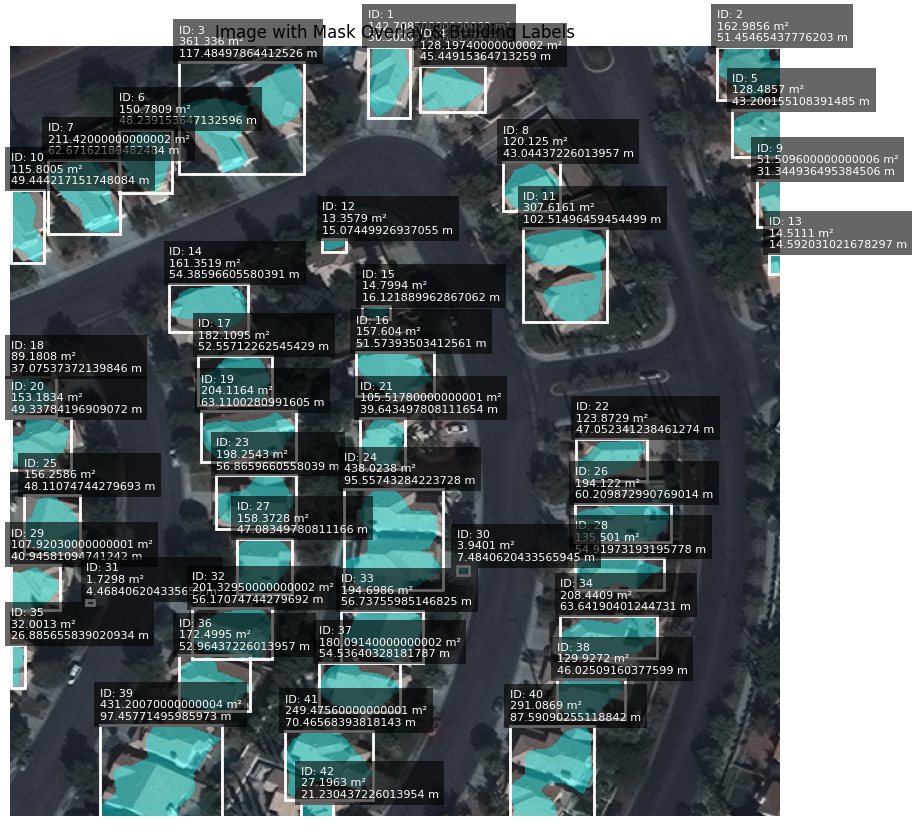

In [37]:
# Example: Overlay the first test image with its predicted mask.
overlay_mask_with_labels(test_image_paths[0], binary_preds[0], alpha=0.4, mask_color='cyan')

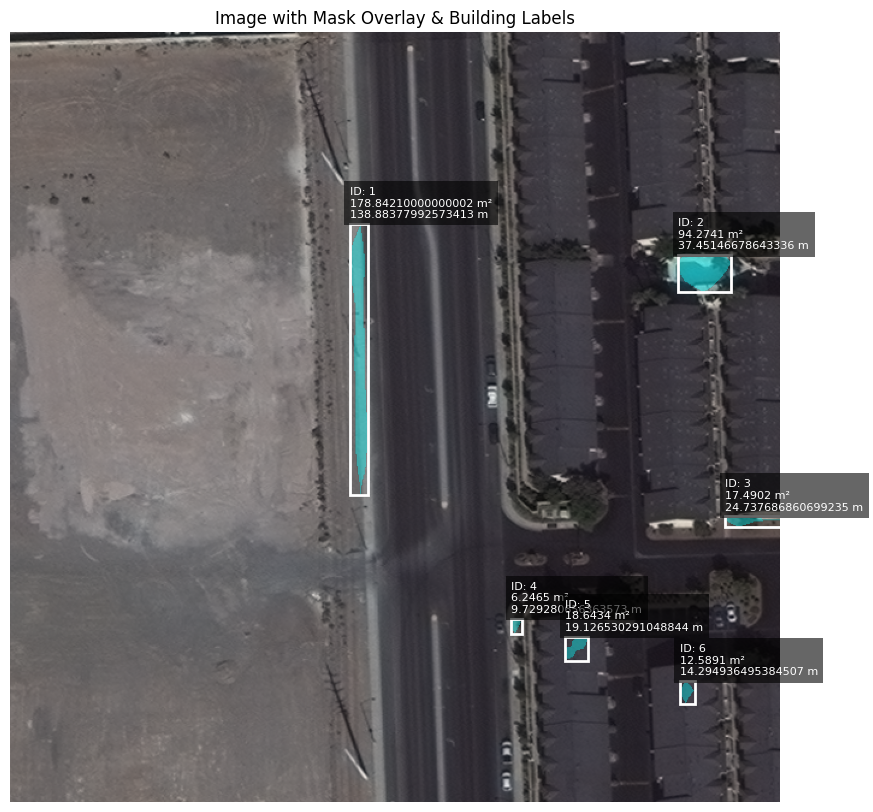

In [38]:
# Example: Overlay the first test image with its predicted mask.
overlay_mask_with_labels(test_image_paths[1], binary_preds[1], alpha=0.4, mask_color='cyan')

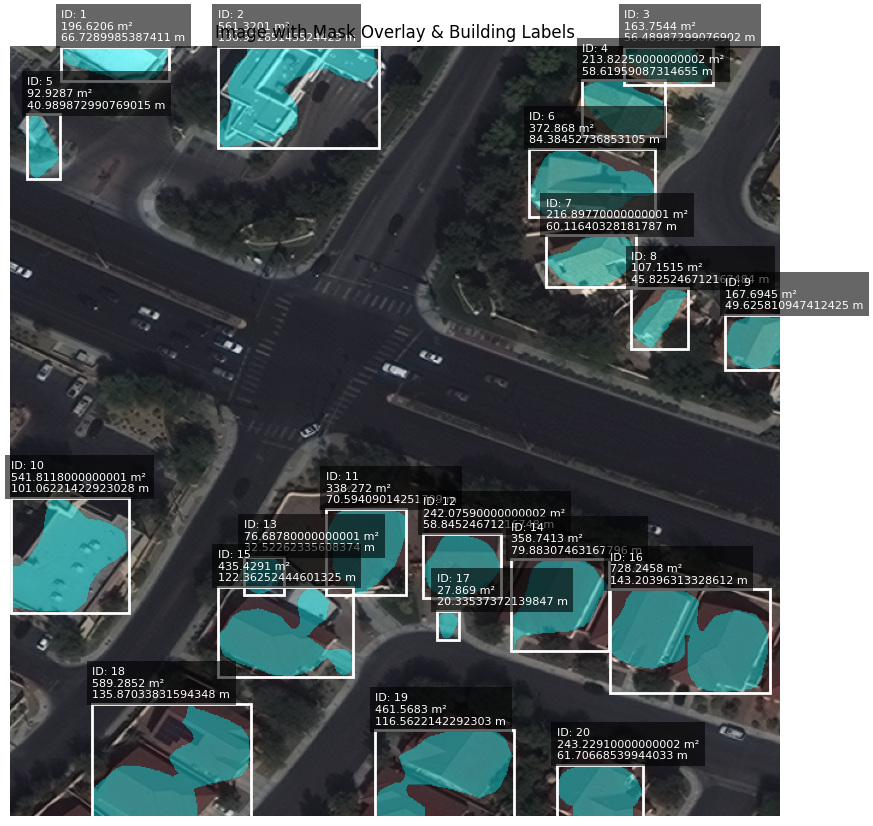

In [39]:
# Example: Overlay the first test image with its predicted mask.
overlay_mask_with_labels(test_image_paths[2], binary_preds[2], alpha=0.4, mask_color='cyan')